# Esercizio 1 - Lezione 4
## Modello sequenziale per la regressione

### Caricamento dati

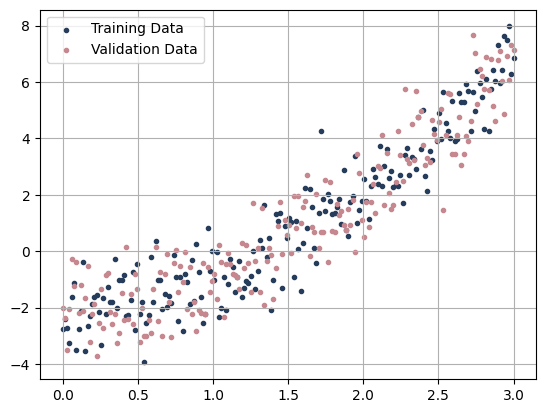

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data.dat')

x_tr = data[:,0]
y_tr = data[:,1]
x_val = data[:,2]
y_val = data[:,3]

plt.scatter(x_tr, y_tr, label='Training Data', c='#253D5B', marker='.')
plt.scatter(x_val, y_val, label='Validation Data', c='#C6878F', marker='.')
plt.grid()
plt.legend()

### Modello lineare di baseline

In [14]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
               loss=tf.keras.losses.MeanSquaredError)

history = model.fit(x_tr, y_tr, epochs=500,
          batch_size = x_tr.shape[0],
          validation_data = (x_val, y_val))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - loss: 4.2617 - val_loss: 4.3651
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.2236 - val_loss: 4.3282
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.1878 - val_loss: 4.2933
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.1539 - val_loss: 4.2603
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.1218 - val_loss: 4.2287
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.0910 - val_loss: 4.1986
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.0616 - val_loss: 4.1696
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.0332 - val_loss: 4.1417
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.0058 - val_loss: 4.1148
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 3.9793 - val_loss: 4.0886
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.9536 - val_loss: 4.0632
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.9285 - val_l

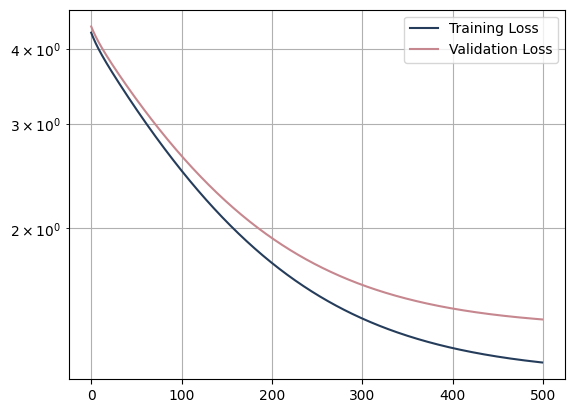

In [15]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


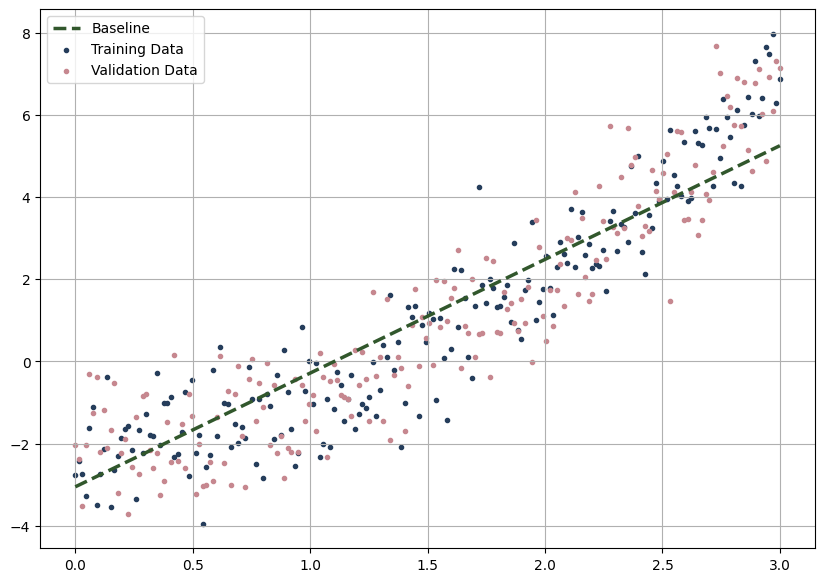

In [16]:
plt.figure(figsize=(10,7))
plt.plot(x_tr, model.predict(x_tr), '--',label='Baseline', color="#31572C", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', c='#253D5B', marker='.')
plt.scatter(x_val, y_val, label='Validation Data', c='#C6878F', marker='.')
plt.grid()
plt.legend()

### Fully connected deep neural network con attivazione leaky-relu

In [17]:
model2 = tf.keras.models.Sequential()

model2.add(tf.keras.layers.Input(shape=(1,)))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(1, activation='linear'))

model2.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss=tf.keras.losses.MSE)

history = model2.fit(x_tr, y_tr, 
                     validation_data=(x_val, y_val), 
                     epochs=500, 
                     batch_size=x_tr.shape[0])

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - loss: 8.2861 - val_loss: 7.9906
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 8.0056 - val_loss: 7.5970
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 7.6032 - val_loss: 7.2076
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 7.2043 - val_loss: 6.8218
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 6.8082 - val_loss: 6.4446
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 6.4197 - val_loss: 6.0852
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 6.0484 - val_loss: 5.7552
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 5.7060 - val_loss: 5.4643
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 5.4025 - val_loss: 5.2164
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 5.1426 - val_loss: 5.0081
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 4.9233 - val_loss: 4.8301
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4.7356 - val_l

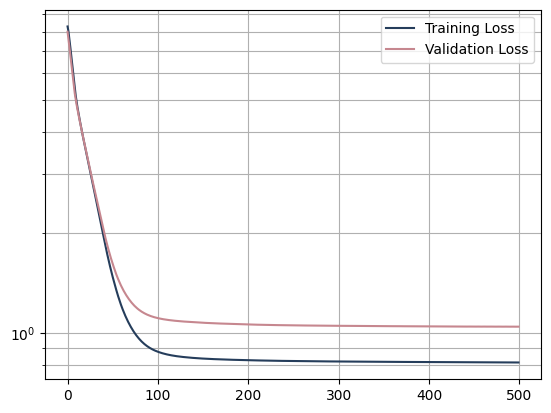

In [18]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


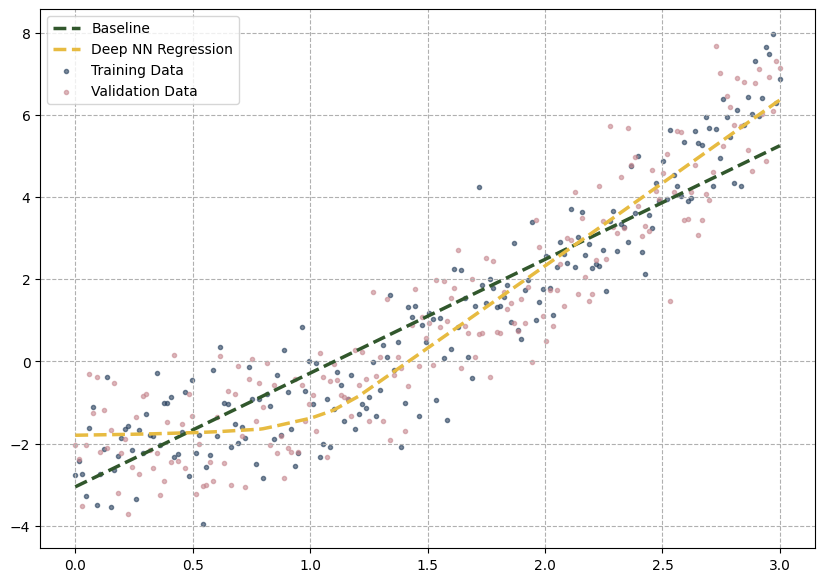

In [19]:
plt.figure(figsize=(10,7))
plt.grid(linestyle='--')
plt.plot(x_val, model.predict(x_val), '--', label='Baseline', color="#31572C", linewidth=2.5)
plt.plot(x_val, model2.predict(x_val), '--', label='Deep NN Regression', color="#E7BB41", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', marker='.', c='#253D5B', alpha=0.6)
plt.scatter(x_val, y_val, label='Validation Data', marker='.', c='#C6878F', alpha=0.6)
plt.legend()

### Fully connected deep neural network con relu

In [20]:

model3 = tf.keras.models.Sequential()

model3.add(tf.keras.layers.Input(shape=(1,)))
model3.add(tf.keras.layers.Dense(10, activation='relu'))
model3.add(tf.keras.layers.Dense(10, activation='relu'))
model3.add(tf.keras.layers.Dense(10, activation='relu'))
model3.add(tf.keras.layers.Dense(1, activation='linear'))

model3.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss=tf.keras.losses.MSE)

history = model3.fit(x_tr, y_tr, 
                     validation_data=(x_val, y_val), 
                     epochs=500, 
                     batch_size=x_tr.shape[0])

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - loss: 4.2541 - val_loss: 4.2979
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 4.1665 - val_loss: 4.2131
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4.0815 - val_loss: 4.1300
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 3.9975 - val_loss: 4.0477
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 3.9140 - val_loss: 3.9646
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 3.8297 - val_loss: 3.8799
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.7442 - val_loss: 3.7921
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.6572 - val_loss: 3.6977
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.5578 - val_loss: 3.6154
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 3.4811 - val_loss: 3.5190
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.3748 - val_loss: 3.4317
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.2833 - val_l

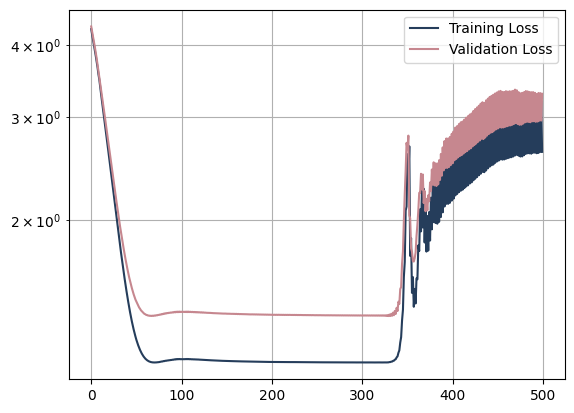

In [21]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


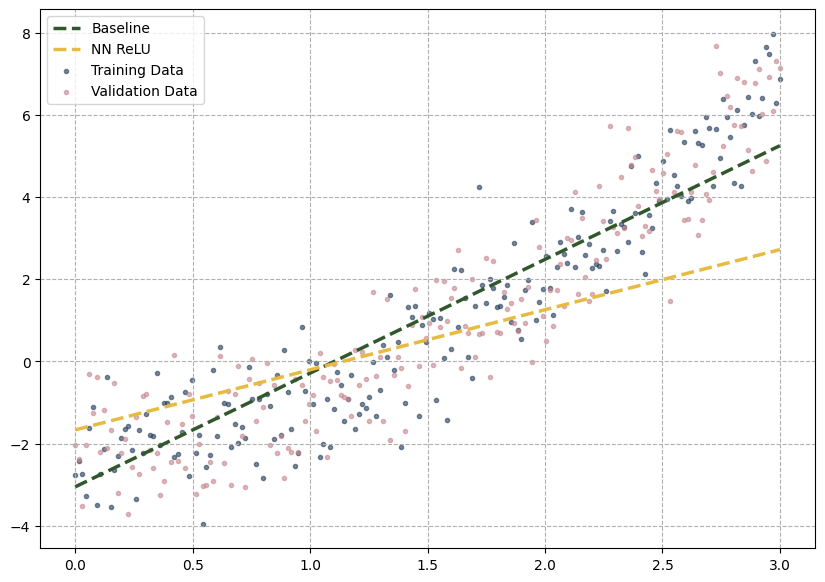

In [22]:
plt.figure(figsize=(10,7))
plt.grid(linestyle='--')
plt.plot(x_val, model.predict(x_val), '--', label='Baseline', color="#31572C", linewidth=2.5)
plt.plot(x_val, model3.predict(x_val), '--', label='NN ReLU', color="#E7BB41", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', marker='.', c='#253D5B', alpha=0.6)
plt.scatter(x_val, y_val, label='Validation Data', marker='.', c='#C6878F', alpha=0.6)
plt.legend()